# Webinar 34 - Sprint 16: Machine Learning para Textos — de Bolsa de Palabras a Embeddings
**Fecha:** 2025-08-18  
**Objetivo:** Entender y practicar el flujo completo de ML para textos: limpieza, lematización (simplificada), vectorización (BoW/n-gramas, TF‑IDF) y representaciones distribuidas (co-ocurrencias + SVD), cerrando con un clasificador sencillo de sentimiento.

## Agenda
- 00:00–00:10 — **Introducción** (flujo NLP clásico, tareas y tipos de representación)
- 00:10–00:35 — **Vectorización de textos** (regex, “lematización” simple, BoW y n‑gramas, TF‑IDF)
- 00:35–01:05 — **Mini proyecto**: Análisis de sentimiento con TF‑IDF + Regresión Logística
- 01:05–01:25 — **Representaciones del lenguaje**: co‑ocurrencias + SVD (idea de embeddings) y clasificación por “promedio de embeddings”
- 01:25–01:30 — **BERT (visión general)** y cierre


## 01. Introducción
En **NLP para Data Science** solemos seguir este flujo:
1. **Recolección** de textos y etiquetas (si hay aprendizaje supervisado).
2. **Limpieza y normalización** (minúsculas, quitar ruido, normalizar tildes, URLs, menciones, etc.).
3. **Preprocesamiento lingüístico** (tokenización, *stemming* o lematización).
4. **Vectorización** para convertir texto → vectores numéricos:  
   - **Bolsa de palabras (BoW)** y **n‑gramas**.
   - **TF‑IDF** para ponderar términos.
   - **Representaciones distribuidas** (*embeddings*), p. ej. Word2Vec, GloVe, BERT.
5. **Modelo** (clasificador/regresor) + **evaluación**.
6. **Iteración** (features, modelos, regularización, etc.).

> En esta clase trabajaremos con un dataset pequeño creado *in‑notebook* para que todo sea reproducible sin descargas.


In [23]:
# === Setup: librerías que usaremos ===
import re, math, random, string, itertools
import numpy as np
import pandas as pd

from collections import Counter, defaultdict
from typing import List, Tuple

# Scikit-learn para vectorización y modelo
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# Matplotlib para una o dos gráficas simples
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

print("Librerías cargadas")


Librerías cargadas


### Dataset de juguete (sentimiento binario)
Creamos un conjunto pequeño en español con opiniones **positivas** y **negativas**.
> *En producción usarías datos reales (reseñas, tweets, feedback de clientes, etc.).*


In [3]:
# --- Generación de un dataset simple de sentimiento (pos/neg) ---
positivos = [
    "Me encantó el producto, funciona perfecto",
    "Excelente calidad y entrega rápida",
    "Muy satisfecho con la compra, recomendable",
    "El servicio al cliente fue genial",
    "La comida estuvo deliciosa y fresca",
    "La app es intuitiva y muy útil",
    "Superó mis expectativas totalmente",
    "Buena relación calidad precio",
    "El teléfono va rápido y la batería dura mucho",
    "Me gusta el diseño y es cómodo de usar",
    "Es fantástico, lo volvería a comprar",
    "Producto confiable y de muy buena calidad",
    "Atención amable y tiempos de respuesta cortos",
    "Pantalla brillante y cámara sorprendente",
    "Entrega puntual y embalaje impecable",
]

negativos = [
    "Muy mala experiencia, no lo recomiendo",
    "El producto llegó dañado y tarde",
    "Pésima calidad, se rompió al primer uso",
    "El servicio al cliente no responde",
    "La comida estaba fría y sin sabor",
    "La app se cuelga y es confusa",
    "No cumplió con lo prometido",
    "Demasiado caro para lo que ofrece",
    "El teléfono es lento y la batería dura poco",
    "No me gusta el diseño, es incómodo",
    "Terrible, jamás volvería a comprar",
    "No es confiable, materiales baratos",
    "Atención grosera y tiempos de espera largos",
    "Pantalla opaca y cámara decepcionante",
    "Entrega retrasada y embalaje deficiente",
]




In [24]:
positivos

['Me encantó el producto, funciona perfecto',
 'Excelente calidad y entrega rápida',
 'Muy satisfecho con la compra, recomendable',
 'El servicio al cliente fue genial',
 'La comida estuvo deliciosa y fresca',
 'La app es intuitiva y muy útil',
 'Superó mis expectativas totalmente',
 'Buena relación calidad precio',
 'El teléfono va rápido y la batería dura mucho',
 'Me gusta el diseño y es cómodo de usar',
 'Es fantástico, lo volvería a comprar',
 'Producto confiable y de muy buena calidad',
 'Atención amable y tiempos de respuesta cortos',
 'Pantalla brillante y cámara sorprendente',
 'Entrega puntual y embalaje impecable']

In [25]:
negativos

['Muy mala experiencia, no lo recomiendo',
 'El producto llegó dañado y tarde',
 'Pésima calidad, se rompió al primer uso',
 'El servicio al cliente no responde',
 'La comida estaba fría y sin sabor',
 'La app se cuelga y es confusa',
 'No cumplió con lo prometido',
 'Demasiado caro para lo que ofrece',
 'El teléfono es lento y la batería dura poco',
 'No me gusta el diseño, es incómodo',
 'Terrible, jamás volvería a comprar',
 'No es confiable, materiales baratos',
 'Atención grosera y tiempos de espera largos',
 'Pantalla opaca y cámara decepcionante',
 'Entrega retrasada y embalaje deficiente']

In [26]:
# Para darle algo de variedad, creamos ligeras variantes
def perturbar(oracion):
    adiciones = ["!", ".", " :)", " :(", " de verdad", " en serio"]
    return oracion + random.choice(adiciones)

textos = [perturbar(s) for s in positivos] + [perturbar(s) for s in negativos]
etiquetas = [1]*len(positivos) + [0]*len(negativos)

df = pd.DataFrame({"texto": textos, "sentimiento": etiquetas})
df.sample(5, random_state=42)

,texto,sentimiento
27,Atención grosera y tiempos de espera largos en...,0
15,"Muy mala experiencia, no lo recomiendo :(",0
23,El teléfono es lento y la batería dura poco!,0
17,"Pésima calidad, se rompió al primer uso!",0
8,El teléfono va rápido y la batería dura mucho ...,1


## 02. Vectorización de textos
En esta sección vamos a:
- **Lematizar (simple)**: normalización muy básica para ilustrar la idea.
- **Expresiones regulares (regex)**: limpieza de URLs, menciones, puntuación, múltiple espacio.
- **Bolsa de palabras y n‑gramas** con `CountVectorizer`.
- **TF‑IDF** con `TfidfVectorizer` y uso en `scikit-learn`.
- **Mini análisis de sentimiento** con TF‑IDF + Regresión Logística.


### 2.1 “Lematización” simplificada (solo para demostración)
> Una lematización real requiere librerías y modelos lingüísticos (p. ej., spaCy + `es_core_news_sm`).  
> Aquí hacemos una **normalización mínima**: minúsculas, quitar tildes y reglas simples (plural→singular, gerundios → raíz).


In [27]:
# --- Utilidades de limpieza ---
import unicodedata

def quitar_tildes(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalizar_basico(s: str) -> str:
    # a) a minúsculas
    s = s.lower()
    # b) quitar tildes
    s = quitar_tildes(s)
    # c) eliminar URLs y menciones
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"@\w+", " USUARIO ", s)
    # d) eliminar dígitos
    s = re.sub(r"\d+", " ", s)
    # e) eliminar puntuación
    s = s.translate(str.maketrans("", "", string.punctuation))
    # f) colapsar espacios
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [8]:
# --- "Lematizador" casero MUY sencillo (solo para ilustrar) ---
def pseudo_lemmatize(token: str) -> str:
    # Reglas mínimas: plurales y gerundios
    if token.endswith("es") and len(token) > 3:
        token = token[:-2]
    elif token.endswith("s") and len(token) > 3:
        token = token[:-1]
    for suf in ("ando","iendo","yendo"):
        if token.endswith(suf) and len(token) > len(suf)+1:
            token = token[:-len(suf)]
    # Diccionario manual para algunos casos comunes
    dic = {
        "entregas":"entrega","entrego":"entregar","entregue":"entregar",
        "rapida":"rapido","rapidas":"rapido","rapidos":"rapido",
        "lento":"lento","rapido":"rapido","cara":"caro"
    }
    return dic.get(token, token)

def limpiar_y_lemmatizar(texto: str) -> List[str]:
    txt = normalizar_basico(texto)
    tokens = txt.split()
    return [pseudo_lemmatize(t) for t in tokens]

In [9]:
# Demo
ejemplo = df["texto"].iloc[0]
print("Original:", ejemplo)
print("Tokens:", limpiar_y_lemmatizar(ejemplo))

Original: Me encantó el producto, funciona perfecto en serio
Tokens: ['me', 'encanto', 'el', 'producto', 'funciona', 'perfecto', 'en', 'serio']


### 2.2 Expresiones regulares útiles
*Patrones frecuentes:*
- `http(s)?://` para URLs
- `@\w+` para menciones
- `[^\w\s]` o usar `str.translate` para quitar puntuación
- `\s+` para colapsar espacios


In [28]:
# Ejemplo rápido de limpieza con regex
raw = "Esto es una prueba!!! visita https://example.com y escribe a @soporte :)"
print("Antes:", raw)
print("Después:", normalizar_basico(raw))


Antes: Esto es una prueba!!! visita https://example.com y escribe a @soporte :)
Después: esto es una prueba visita URL y escribe a USUARIO


### 2.3 Bolsa de Palabras (BoW) y n‑gramas
Con `CountVectorizer`:
- `ngram_range=(1,1)` → unigrams; `(1,2)` → unigrams + bigrams.
- `min_df` para filtrar términos raros; `max_df` para filtrar términos muy comunes.


In [30]:
# Vectorización: CountVectorizer con n-gramas
cv = CountVectorizer(tokenizer=limpiar_y_lemmatizar, ngram_range=(1,2), min_df=1)
X_bow = cv.fit_transform(df["texto"])

In [31]:
X_bow

<30x259 sparse matrix of type '<class 'numpy.int64'>'
	with 395 stored elements in Compressed Sparse Row format>

In [32]:
print("Shape BoW:", X_bow.shape)
# Mostramos algunas características
vocab = np.array(cv.get_feature_names_out())
print("Ejemplo de vocabulario:", vocab[:20])

Shape BoW: (30, 259)
Ejemplo de vocabulario: ['a' 'a comprar' 'al' 'al cliente' 'al primer' 'amable' 'amable y' 'app'
 'app es' 'app se' 'atencion' 'atencion amable' 'atencion grosera'
 'barato' 'barato en' 'bateria' 'bateria dura' 'brillante' 'brillante y'
 'buena']


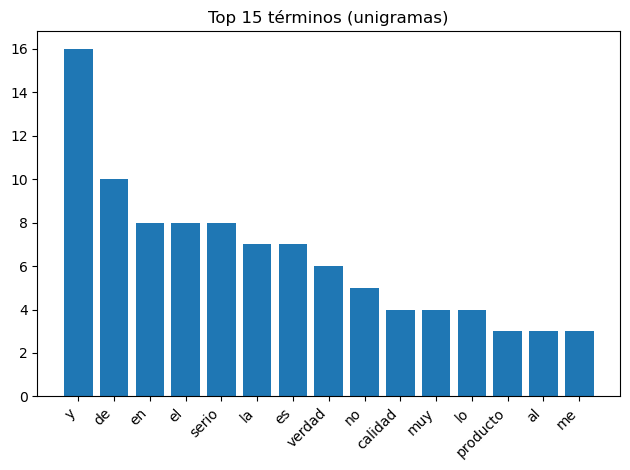

In [33]:
# Visual: top términos por frecuencia (unigramas)
unigram_cv = CountVectorizer(tokenizer=limpiar_y_lemmatizar, ngram_range=(1,1))
X_uni = unigram_cv.fit_transform(df["texto"])
freqs = np.asarray(X_uni.sum(axis=0)).ravel()
terms = np.array(unigram_cv.get_feature_names_out())

top_idx = freqs.argsort()[::-1][:15]
plt.figure()
plt.bar(range(len(top_idx)), freqs[top_idx])
plt.xticks(range(len(top_idx)), terms[top_idx], rotation=45, ha='right')
plt.title("Top 15 términos (unigramas)")
plt.tight_layout()
plt.show()


### 2.4 TF‑IDF (teoría breve)
- **TF**: frecuencia de término dentro de un documento.
- **IDF**: penaliza términos demasiado comunes en la colección.
- **TF·IDF** resalta términos *característicos* de cada documento.


In [13]:
# TF-IDF con scikit-learn
tfidf = TfidfVectorizer(tokenizer=limpiar_y_lemmatizar, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df["texto"])
print("Shape TF-IDF:", X_tfidf.shape)


Shape TF-IDF: (30, 259)


C:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [14]:
# Mostrar términos con mayor peso en un documento ejemplo
doc_id = 0
row = X_tfidf[doc_id].toarray().ravel()
idx = row.argsort()[::-1][:10]
terms = tfidf.get_feature_names_out()
print("Documento:", df['texto'].iloc[doc_id])
print("Top 10 términos por TF-IDF:")
for i in idx:
    if row[i] > 0:
        print(f"{terms[i]} -> {row[i]:.3f}")

Documento: Me encantó el producto, funciona perfecto en serio
Top 10 términos por TF-IDF:
me encanto -> 0.294
encanto el -> 0.294
perfecto -> 0.294
perfecto en -> 0.294
producto funciona -> 0.294
encanto -> 0.294
funciona -> 0.294
funciona perfecto -> 0.294
el producto -> 0.262
producto -> 0.240


### 2.5 Ejercicio guiado (rápido)
**Tarea:** Ajusta `ngram_range`, `min_df` y `max_df` en `TfidfVectorizer` y observa:
1) Cómo cambia el `shape` de la matriz.  
2) Cómo cambian los términos con mayor TF‑IDF del `doc_id`.


In [15]:
# === Tu turno: modifica estos hiperparámetros ===
ngram_range = (1,2)
min_df = 1
max_df = 1.0

tfidf_ex = TfidfVectorizer(tokenizer=limpiar_y_lemmatizar,
                           ngram_range=ngram_range,
                           min_df=min_df,
                           max_df=max_df)
X_ex = tfidf_ex.fit_transform(df["texto"])
print("Nuevo shape:", X_ex.shape)

Nuevo shape: (30, 259)


In [16]:
doc_id = 1
row = X_ex[doc_id].toarray().ravel()
idx = row.argsort()[::-1][:10]
terms = tfidf_ex.get_feature_names_out()
print("Documento:", df['texto'].iloc[doc_id])
print("Top términos TF-IDF con los nuevos parámetros:")
for i in idx:
    if row[i] > 0:
        print(f"{terms[i]} -> {row[i]:.3f}")

Documento: Excelente calidad y entrega rápida!
Top términos TF-IDF con los nuevos parámetros:
entrega rapido -> 0.372
y entrega -> 0.372
excelente calidad -> 0.372
calidad y -> 0.372
excelente -> 0.372
rapido -> 0.332
entrega -> 0.303
calidad -> 0.281
y -> 0.159


### 2.6 Mini-proyecto: Análisis de sentimiento con TF‑IDF + Regresión Logística
**Pasos:**
1. Split train/test.
2. Vectorizar con TF‑IDF.
3. Entrenar `LogisticRegression`.
4. Evaluar con *accuracy*, *confusion_matrix* y *classification_report*.


In [34]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"],
    df["sentimiento"],
    test_size=0.25,
    random_state=42,
    stratify=df["sentimiento"]
)

In [36]:
y_train

3     1
26    0
23    0
24    0
22    0
16    0
20    0
12    1
29    0
28    0
17    0
1     1
15    0
13    1
11    1
0     1
8     1
9     1
19    0
6     1
4     1
10    1
Name: sentimiento, dtype: int64

In [37]:
# Vectorizador (con tokenizer propio)
vectorizer = TfidfVectorizer(
    tokenizer=limpiar_y_lemmatizar,
    ngram_range=(1, 2),
    min_df=1,
    token_pattern=None  # opcional: evita el warning
)
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)


In [40]:
# Modelo
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

In [41]:
# Métricas (usando round() global o formato)
acc = accuracy_score(y_test, pred)
print(f"Accuracy: {acc:.3f}")
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred))
print("\nReporte de clasificación:\n", classification_report(y_test, pred, digits=3))


Accuracy: 0.250

Matriz de confusión:
 [[1 3]
 [3 1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.250     0.250     0.250         4
           1      0.250     0.250     0.250         4

    accuracy                          0.250         8
   macro avg      0.250     0.250     0.250         8
weighted avg      0.250     0.250     0.250         8



## 03. Representaciones del lenguaje (Embeddings “caseros”)
En lugar de *contar palabras*, los **embeddings** representan términos en un espacio continuo de baja dimensión donde la **similitud semántica** se refleja en **distancias**.

### Idea práctica (rápida, sin librerías externas):
1. Construimos una **matriz de co‑ocurrencias** término‑término (ventana pequeña).
2. Calculamos una transformación (p. ej., `log(1 + cooc)` o PMI simple).
3. Aplicamos **SVD truncado** para obtener vectores densos (dimensión `k`).
> Esto no es Word2Vec/BERT, pero ilustra el salto de BoW → representaciones densas.


In [18]:
# --- Construir vocabulario y co-ocurrencias ---
token_docs = [limpiar_y_lemmatizar(t) for t in df["texto"]]

# Vocabulario
vocab = sorted(set(itertools.chain.from_iterable(token_docs)))
idx_of = {w:i for i,w in enumerate(vocab)}
V = len(vocab)

# Matriz de co-ocurrencias simétrica con ventana=2
window = 2
cooc = np.zeros((V,V), dtype=np.float64)

for tokens in token_docs:
    for i, w in enumerate(tokens):
        wi = idx_of[w]
        L = max(0, i-window)
        R = min(len(tokens), i+window+1)
        for j in range(L, R):
            if j == i: 
                continue
            wj = idx_of[tokens[j]]
            cooc[wi, wj] += 1.0
            cooc[wj, wi] += 1.0

# Suavizado log(1 + x)
X = np.log1p(cooc)
print("Vocab size:", V, " - Matriz:", X.shape)


Vocab size: 108  - Matriz: (108, 108)


In [19]:
# --- SVD truncado para obtener embeddings densos ---
k = 50 if len(vocab) > 50 else max(2, len(vocab)//2)  # dimensión pequeña
svd = TruncatedSVD(n_components=k, random_state=42)
W = svd.fit_transform(X)   # shape: (V, k)

# Normalizamos para usar coseno fácilmente
Wn = normalize(W)

def palabra_a_vec(p):
    i = idx_of.get(p, None)
    return Wn[i] if i is not None else None

def vecinos(p, top=8):
    v = palabra_a_vec(p)
    if v is None:
        return []
    sims = Wn @ v
    order = np.argsort(-sims)
    out = []
    for j in order[:top+1]:
        if vocab[j] != p:
            out.append((vocab[j], float(sims[j])))
    return out[:top]

print("Vecinos de 'rapido':", vecinos("rapido"))
print("Vecinos de 'lento':",  vecinos("lento"))


Vecinos de 'rapido': [('lento', 0.7908362129556478), ('puntual', 0.6328987307534031), ('retrasada', 0.6328987307534031), ('va', 0.6273712390404207), ('estuvo', 0.5733172961756162), ('bateria', 0.5682892754634287), ('estaba', 0.558294931148485), ('tarde', 0.509353955846664)]
Vecinos de 'lento': [('rapido', 0.7908362129556478), ('confusa', 0.7527230025538497), ('comodo', 0.620144307791702), ('estuvo', 0.6049152505771797), ('bateria', 0.5970860173785137), ('estaba', 0.5758582908846335), ('app', 0.5679593328680478), ('cuelga', 0.558641887996087)]


### 3.1 Clasificación con “promedio de embeddings”
Convertimos cada documento en el **promedio** de los vectores de sus palabras (muy usado como baseline).


In [22]:
def doc_embedding(tokens: List[str]) -> np.ndarray:
    vecs = [palabra_a_vec(t) for t in tokens if palabra_a_vec(t) is not None]
    if not vecs:
        return np.zeros(Wn.shape[1])
    return np.mean(vecs, axis=0)

X_emb = np.vstack([doc_embedding(tokens) for tokens in token_docs])
y = df["sentimiento"].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_emb, y, test_size=0.25, random_state=42, stratify=y
)

clf_e = LogisticRegression(max_iter=1000)
clf_e.fit(X_train_e, y_train_e)
pred_e = clf_e.predict(X_test_e)

acc = accuracy_score(y_test_e, pred_e)
print(f"Accuracy (embeddings SVD): {acc:.3f}")
print("\nMatriz de confusión:\n", confusion_matrix(y_test_e, pred_e))
print("\nReporte de clasificación:\n", classification_report(y_test_e, pred_e, digits=3))

Accuracy (embeddings SVD): 0.375

Matriz de confusión:
 [[2 2]
 [3 1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.400     0.500     0.444         4
           1      0.333     0.250     0.286         4

    accuracy                          0.375         8
   macro avg      0.367     0.375     0.365         8
weighted avg      0.367     0.375     0.365         8



### 3.2 Word2Vec (comentario)
- Word2Vec aprende embeddings **prediciendo contexto** (CBOW) o **prediciendo palabra objetivo** (Skip‑gram).
- Requiere más datos para ser útil, y normalmente usarás librerías como **gensim**.

> *Si tienes `gensim` instalado y un corpus suficiente, entrenarías algo como:*
```python
from gensim.models import Word2Vec
sentences = token_docs
w2v = Word2Vec(sentences=sentences, vector_size=50, window=2, min_count=1, workers=2, sg=1)
w2v.wv.most_similar("rapido")
```


### 3.3 BERT (visión general) & preprocesamiento
- **BERT** (Transformer bidireccional) produce **representaciones contextuales** por token y por oración.
- En la práctica usarías `transformers` de HuggingFace o `sentence-transformers` para obtener embeddings listos.
- **Preprocesamiento** típico: limpieza ligera (pero no “rompas” el texto), *tokenizer* de BERT (WordPiece), *padding* y *truncation*.

> *Ejemplo práctico (si tienes `sentence-transformers`):*
```python
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embs = model.encode(df["texto"].tolist(), show_progress_bar=False)
# Luego, entrenas un clasificador con esos embeddings
```


## Conclusión
- Empezamos con **BoW/n‑gramas** y **TF‑IDF**, que suelen ser **fuertes baselines** para textos cortos.
- Luego exploramos **representaciones densas** con co‑ocurrencias+SVD (didáctico para entender embeddings).
- En producción, embeddings **pre‑entrenados** (Word2Vec, fastText) o modelos **contextuales** (BERT/SBERT) suelen rendir mejor, especialmente con datos limitados.

---

### Retos (para practicar después)
1. Añade **stopwords** (lista manual) y compara *accuracy*.
2. Ajusta **C** en `LogisticRegression` y reporta cambios.
3. Prueba `ngram_range=(1,3)` y limita vocabulario con `max_features`.
4. Cambia el tamaño de ventana de co‑ocurrencias y la dimensión `k` del SVD.
